# 🛒 Milestone 2 — Computer Vision
This notebook trains a custom Convolutional Neural Network (CNN) from scratch and a pre-trained `MobileNetV2` model via transfer learning to classify product categories directly from cached catalog images.

In [1]:
import sys
import os
# Add project root to path so we can import src modules
sys.path.append(os.path.abspath(os.path.join('..')))

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from src.models import build_vision_cnn, build_vision_mobilenet
from src.utils import evaluate_classification, plot_confusion_matrix, plot_learning_curves

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Data Loader & Image Generators
We load `products_split.parquet` and filter for products that have a successfully downloaded local image.

In [2]:
products_path = "data/processed/products_split.parquet"
if not os.path.exists(products_path):
    products_path = "../data/processed/products_split.parquet"
if not os.path.exists(products_path):
    products_path = "../data/processed/products_split.parquet"
image_dir = "data/images/"
if not os.path.exists(image_dir):
    image_dir = "../data/images/"
if not os.path.exists(image_dir):
    image_dir = "../data/images/"

if not os.path.exists(products_path):
    raise FileNotFoundError("Please run M0 data download first.")

df_prod = pd.read_parquet(products_path)
print(f"Total unique products in dataset: {len(df_prod)}")

# Verify local image file paths exist on disk
def get_local_image_path(parent_asin):
    for ext in ['.jpg', '.png']:
        path = os.path.join(image_dir, f"{parent_asin}{ext}")
        if os.path.exists(path):
            return path
    return None

df_prod['local_path'] = df_prod['parent_asin'].apply(get_local_image_path)
df_prod_clean = df_prod[df_prod['local_path'].notna()].copy()
print(f"Products with cached local images: {len(df_prod_clean)}")

Total unique products in dataset: 10000
Products with cached local images: 9999


In [3]:
# Filter for Top Categories to ensure clean category classification signal
df_prod_clean['primary_category'] = df_prod_clean['categories_str'].apply(lambda x: x.split(',')[1].strip() if len(x.split(',')) > 1 else 'Unknown'.strip() if x else 'Unknown')

top_categories = df_prod_clean['primary_category'].value_counts().index[:5].tolist()
df_filtered = df_prod_clean[df_prod_clean['primary_category'].isin(top_categories)].copy()

print(f"Selected Top 5 Categories: {top_categories}")
print(f"Filtered dataset has {len(df_filtered)} items.")

Selected Top 5 Categories: ['Computers & Accessories', 'Camera & Photo', 'Headphones', 'Television & Video', 'Accessories & Supplies']
Filtered dataset has 7754 items.


In [4]:
# Encode targets
encoder = LabelEncoder()
df_filtered['label'] = encoder.fit_transform(df_filtered['primary_category'])
num_classes = len(top_categories)
print("Class labels mapped:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

# Set up generator dataframes
df_filtered['label_str'] = df_filtered['label'].astype(str)
train_df = df_filtered[df_filtered['split'] == 'train'].sample(n=min(500, len(df_filtered[df_filtered['split'] == 'train'])), random_state=42)
val_df = df_filtered[df_filtered['split'] == 'val'].sample(n=min(150, len(df_filtered[df_filtered['split'] == 'val'])), random_state=42)
test_df = df_filtered[df_filtered['split'] == 'test'].sample(n=min(150, len(df_filtered[df_filtered['split'] == 'test'])), random_state=42)

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}")

Class labels mapped: {'Accessories & Supplies': 0, 'Camera & Photo': 1, 'Computers & Accessories': 2, 'Headphones': 3, 'Television & Video': 4}
Train size: 500, Val size: 150, Test size: 150


In [5]:
# Image Generators with Augmentation for Train
img_size = (96, 96)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='local_path',
    y_col='label_str',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='local_path',
    y_col='label_str',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='local_path',
    y_col='label_str',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

Found 500 validated image filenames belonging to 5 classes.
Found 150 validated image filenames belonging to 5 classes.
Found 150 validated image filenames belonging to 5 classes.


## 2. Train Custom CNN from Scratch

In [6]:
input_shape = img_size + (3,)
scratch_model = build_vision_cnn(input_shape, num_classes)
scratch_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

scratch_checkpoint = "data/checkpoints/vision_cnn_scratch.keras"
callbacks_scratch = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint(filepath=scratch_checkpoint, monitor='val_loss', save_best_only=True)
]

print("Training Custom CNN from scratch...")
history_scratch = scratch_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    callbacks=callbacks_scratch,
    verbose=1
)

Training Custom CNN from scratch...
Epoch 1/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 304ms/step - accuracy: 0.5080 - loss: 1.4293 - val_accuracy: 0.5800 - val_loss: 1.3073
Epoch 2/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 260ms/step - accuracy: 0.5280 - loss: 1.3789 - val_accuracy: 0.5800 - val_loss: 1.2505
Epoch 3/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - accuracy: 0.5280 - loss: 1.3540 - val_accuracy: 0.5800 - val_loss: 1.2633


## 3. Train Transfer Learning Model (MobileNetV2)

In [7]:
# Pre-processing layer mapping is built-in inside flow_from_dataframe
# Pretrained model backbone weights are frozen
transfer_model = build_vision_mobilenet(input_shape, num_classes)
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

transfer_checkpoint = "data/checkpoints/vision_mobilenet.keras"
callbacks_transfer = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint(filepath=transfer_checkpoint, monitor='val_loss', save_best_only=True)
]

print("Training MobileNetV2 Transfer Learning...")
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2,
    callbacks=callbacks_transfer,
    verbose=1
)

Training MobileNetV2 Transfer Learning...
Epoch 1/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 387ms/step - accuracy: 0.3460 - loss: 1.9085 - val_accuracy: 0.3800 - val_loss: 1.6450
Epoch 2/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 266ms/step - accuracy: 0.4340 - loss: 1.6750 - val_accuracy: 0.4600 - val_loss: 1.5127


## 4. Evaluation and Comparison

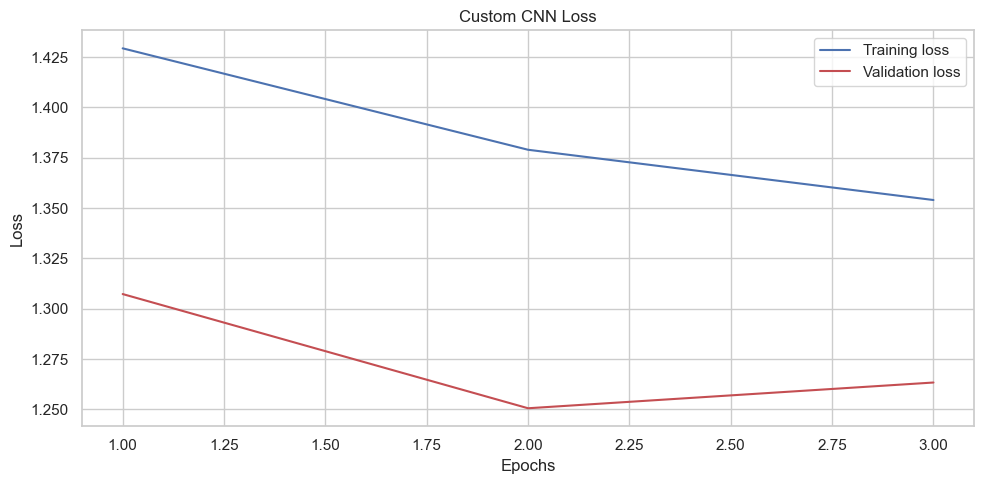

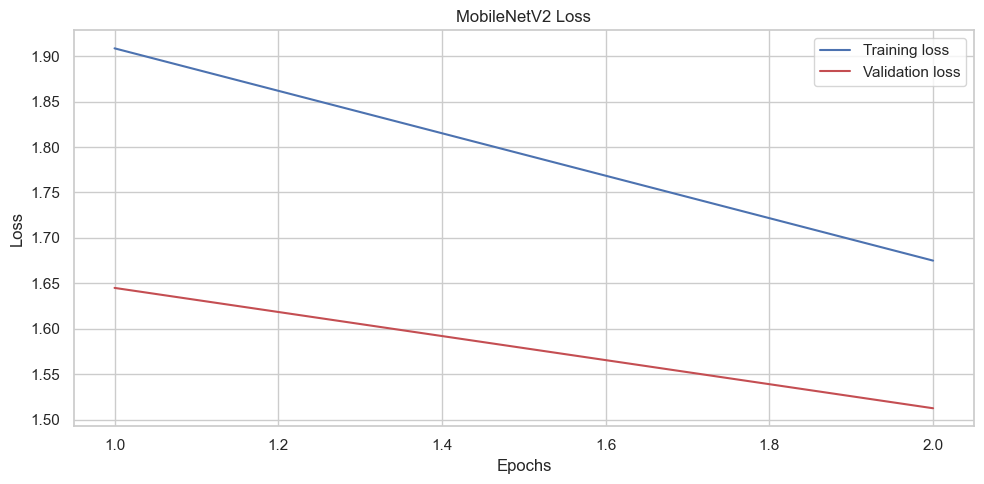

In [8]:
# Plot training curves
plot_learning_curves(history_scratch, metric='loss', title='Custom CNN Loss')
plot_learning_curves(history_transfer, metric='loss', title='MobileNetV2 Loss')

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 382ms/step
=== Scratch CNN Results ===
=== Classification Report ===
                         precision    recall  f1-score   support

 Accessories & Supplies       0.00      0.00      0.00         9
         Camera & Photo       0.00      0.00      0.00        23
Computers & Accessories       0.63      1.00      0.78        95
             Headphones       0.00      0.00      0.00        17
     Television & Video       0.00      0.00      0.00         6

               accuracy                           0.63       150
              macro avg       0.13      0.20      0.16       150
           weighted avg       0.40      0.63      0.49       150

Accuracy: 0.6333
Macro F1 Score: 0.1551


d:\Games\final_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Games\final_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Games\final_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


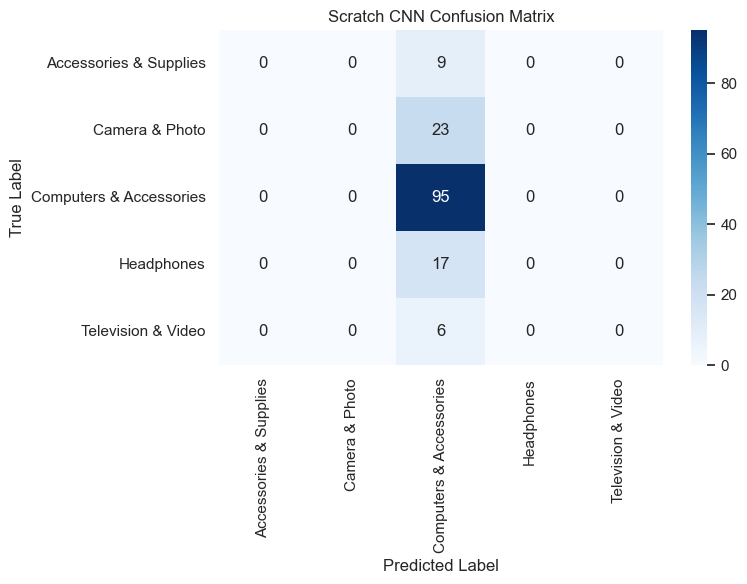

=== MobileNetV2 Results ===
=== Classification Report ===
                         precision    recall  f1-score   support

 Accessories & Supplies       0.12      0.11      0.12         9
         Camera & Photo       0.00      0.00      0.00        23
Computers & Accessories       0.64      0.59      0.61        95
             Headphones       0.23      0.29      0.26        17
     Television & Video       0.10      0.50      0.17         6

               accuracy                           0.43       150
              macro avg       0.22      0.30      0.23       150
           weighted avg       0.44      0.43      0.43       150

Accuracy: 0.4333
Macro F1 Score: 0.2315


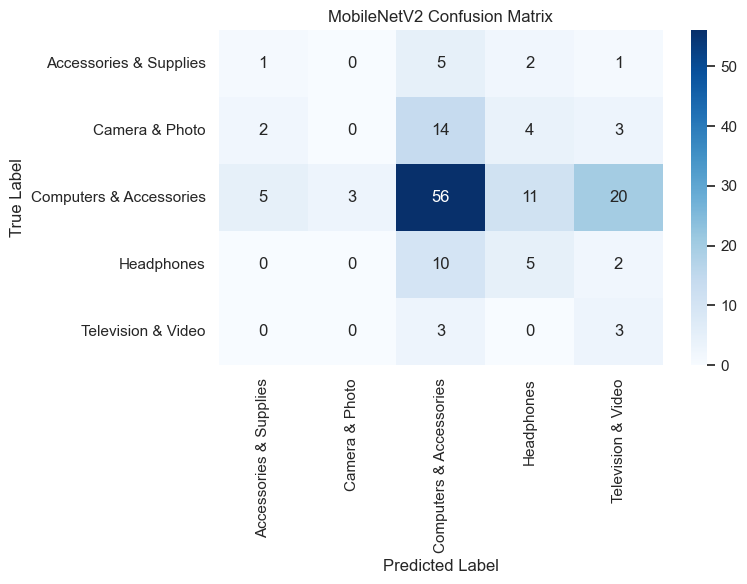

In [9]:
# Predict using custom CNN
test_generator.reset()
y_pred_scratch_probs = scratch_model.predict(test_generator)
y_pred_scratch = np.argmax(y_pred_scratch_probs, axis=1)

# Predict using Transfer learning
test_generator.reset()
y_pred_transfer_probs = transfer_model.predict(test_generator)
y_pred_transfer = np.argmax(y_pred_transfer_probs, axis=1)

y_true = test_generator.classes
classes = list(encoder.classes_)

print("=== Scratch CNN Results ===")
evaluate_classification(y_true, y_pred_scratch, class_names=classes)
plot_confusion_matrix(y_true, y_pred_scratch, class_names=classes, title="Scratch CNN Confusion Matrix")

print("=== MobileNetV2 Results ===")
evaluate_classification(y_true, y_pred_transfer, class_names=classes)
plot_confusion_matrix(y_true, y_pred_transfer, class_names=classes, title="MobileNetV2 Confusion Matrix")